### Heart Failure Prediction Dataset

#### This dataset contains 11 features that can be used to predict possible heart disease.

#### I will implement Tree Ensemble models (Random Forest and XGBoost models) and evaluate them.

#### Complete workflow is done by myself.

In [1]:
import pandas as pd
import numpy as np


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import os       

In [2]:
file_path = str(r"c:\Users\Admin\ML-concepts\datasets\heart.csv")
df = pd.read_csv(file_path)

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Attribute Information

    Age: age of the patient [years]
    Sex: sex of the patient [M: Male, F: Female]
    ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
    RestingBP: resting blood pressure [mm Hg]
    Cholesterol: serum cholesterol [mm/dl]
    FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
    RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
    MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
    ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
    Oldpeak: oldpeak = ST [Numeric value measured in depression]
    ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
    HeartDisease: output class [1: heart disease, 0: Normal]


### Target: HeartDisease -> Binary classification 

- 0 no disease

- 1 disease



### **EDA**

In [4]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
y.value_counts()

# balanced 

total = y.value_counts().sum()

df_y = pd.DataFrame(y.value_counts())
df_y['percentage'] = df_y['count'].apply(lambda row: row/total).round(2)
df_y

,count,percentage
HeartDisease,,
1,508,0.55
0,410,0.45


### Distribution of positive and negative class is fine, no need to stratify 

#### 1.1 Numerical features:

In [5]:
numeric = df.select_dtypes(include='number')
numeric.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [6]:
# Check if missing values exists (exclude target)
numeric = numeric.iloc[:,:-1]
(numeric==0).sum()

Age              0
RestingBP        1
Cholesterol    172
FastingBS      704
MaxHR            0
Oldpeak        368
dtype: int64

#### RestingBP: 1 missing value (impossible to have 0 for BP)

#### Cholesterol: 172 missin values (also impossible to have 0 cholesterol level)

#### FastingBS: 704 missing values (it's not technical missing value, but as the dataset explained, fasting bs < 120mg Glucose has 0 and >120mg has 1)


172 missing values for cholesterol should be corrected, and I may use Imputer method after observing additional key points

In [7]:
numeric['Cholesterol'].describe()

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

### Scale of numerical feature is different, but since I will use Tree based models, there is no need to implement data scaling/normalization

### Numerical features descriptive statistics:

- 918 instances

In [8]:
numeric.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89
std,9.43,18.51,109.38,0.42,25.46,1.07
min,28.00,0.00,0.00,0.00,60.00,-2.60
25%,47.00,120.00,173.25,0.00,120.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60
75%,60.00,140.00,267.00,0.00,156.00,1.50
max,77.00,200.00,603.00,1.00,202.00,6.20


### Cholesterol feature has very high std, which implies heavy influence of outliers, and we may observe from upper data:

1) min = 0

2) max = 603

3) mean = 198

I expect that **cholesterol** has positive (right skew)

In [9]:
#Cleaning form zeros
cholesterol_no_zeros = numeric['Cholesterol']>0
cholesterol_no_zeros = numeric.loc[cholesterol_no_zeros,'Cholesterol']
(cholesterol_no_zeros==0).sum()

np.int64(0)

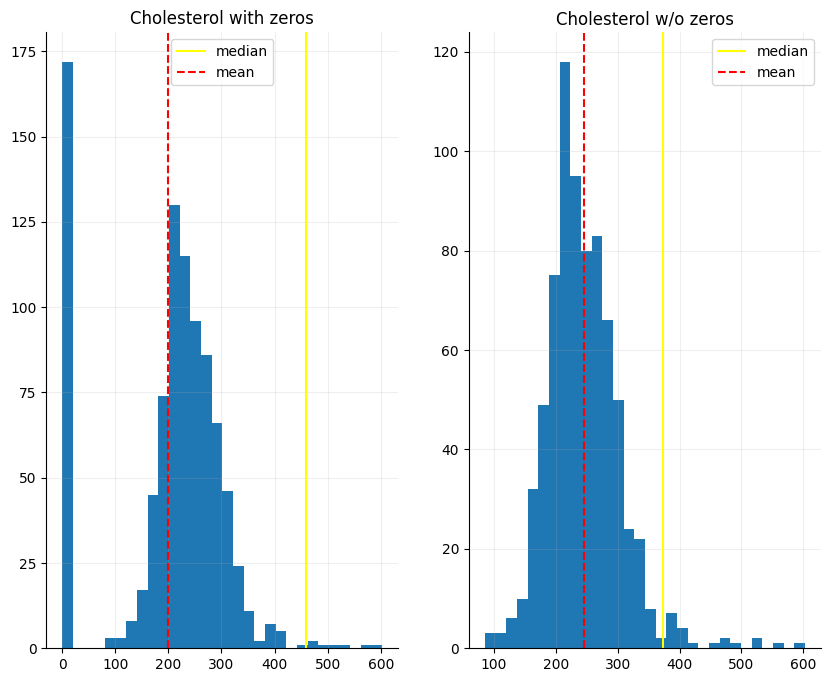

In [10]:
fig,ax = plt.subplots(1,2,figsize=(10,8))

ax[0].hist(df['Cholesterol'],bins=30)
ax[1].hist(cholesterol_no_zeros,bins=30)
n_clean = len(cholesterol_no_zeros)/2
mean_clean = cholesterol_no_zeros.mean()
ax[0].axvline(len(df)/2,label='median',color='yellow')
ax[0].axvline(df['Cholesterol'].mean(),label='mean',color='red',linestyle='--')

ax[1].axvline(n_clean,label='median',color='yellow')
ax[1].axvline(mean_clean,label='mean',color='red',linestyle='--')

ax[0].set_title("Cholesterol with zeros")
ax[1].set_title("Cholesterol w/o zeros")
for ax in ax.flatten():
    ax.spines[['top','right']].set_visible(False)
    ax.legend()
    ax.grid(alpha=0.2)

### Mean > Mode -> Right skew 

Since cholesterol has 171 missing value, and dataset has around 900 instances, it would be a loss to drop these rows where **cholesterol==0**. I consider imputation method, by using Median as a strategy for this dataset and observed distribution.

### 1.2 Categorical features

In [11]:

categorical =  df.select_dtypes(exclude='number')
categorical

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


### Inspection of each category and it's value counts:

In [12]:
for col in categorical.columns:
    print(categorical[col].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [13]:
chest_pain = pd.crosstab(categorical['ChestPainType'],df['HeartDisease'],margins=True)
chest_pain

HeartDisease,0,1,All
ChestPainType,,,
ASY,104,392,496
ATA,149,24,173
NAP,131,72,203
TA,26,20,46
All,410,508,918


#### ChestPain related to a target variable:

In [14]:
chest_pain['percentage_heart_disase'] = chest_pain.apply(lambda row: row[1]/row['All'],axis=1)
chest_pain


HeartDisease,0,1,All,percentage_heart_disase
ChestPainType,,,,
ASY,104,392,496,0.790323
ATA,149,24,173,0.138728
NAP,131,72,203,0.354680
TA,26,20,46,0.434783
All,410,508,918,0.553377


In [15]:
### Resting ECG / Target

rest_ecg = pd.crosstab(categorical['RestingECG'],df['HeartDisease'],normalize='index')
rest_ecg

# ST - indeed strongest contributor to positive class

HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


In [16]:
exercise_angina = pd.crosstab(categorical['ExerciseAngina'],df['HeartDisease'],normalize='index')
exercise_angina

HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


In [17]:
st_slope = pd.crosstab(categorical['ST_Slope'],df['HeartDisease'])
st_slope['%_disease'] = st_slope.apply(lambda row: row[1]/row.sum(),axis=1).round(2)
st_slope

HeartDisease,0,1,%_disease
ST_Slope,,,
Down,14,49,0.78
Flat,79,381,0.83
Up,317,78,0.20


1) Sex - binary

2) ChestPainType - Unordered categorical variable (nominal) - candidate for OneHotEncoder

- ASY -> Asymptomatic **Patients in this category show no chest pain at all.**

- ATA -> Atypical Angina

- TA -> Typical Angina **Classic, heart-related chest pain**

- NAP -> Non-Angianl Pain **Chest discomfort that is not characteristic of heart disease (angina)**

3) RestingECG - Normal, LVH - Left Ventricular hyperthropy (worse patient health), ST - T inversion - Candidate for OHE of this feature (nominal feature)

4) ExerciseAngina - Binary

5) ST_SLope - flat , up , down - cnadidate for ordinal encoder

### 1.3 Correlation heatmap for numeric features /w Target feature (Normalized Variance [-1,1])

- Correlation is matrix of [ features x features ] that shows the interaction between each numeric feature

- Positive annotation -> increasing in one feature leads to increasing in another

- Negatve -> increasing in one leads to decreasing in another and vice versa

- If feature has negative correlation with a Target Feature, it does not mean that feature should be excluded. Correlation does not imply causality.

<Axes: >

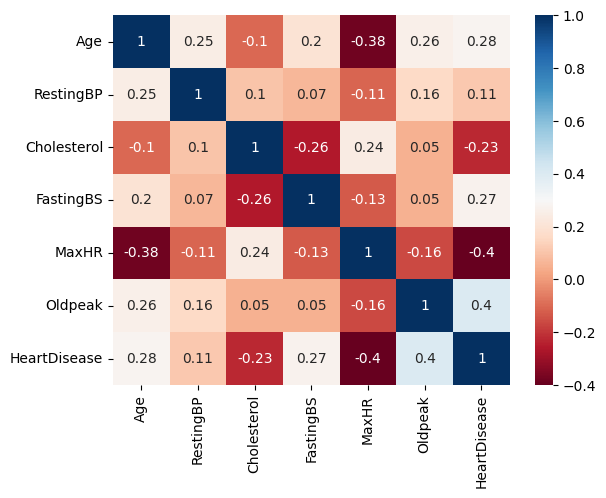

In [18]:
numeric = df.select_dtypes(include='number')

sns.heatmap(numeric.corr().round(2),cmap='RdBu',annot=True)

### 1.4 EDA visualisation of the data ( Numerical features ):

1) **using correlation matrix to plot meaningful data correlation**


In [19]:
corr_matrix = numeric.corr()
corr_matrix

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


In [20]:
# FastingBS (numeric but not continous!)

numeric['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

In [21]:
abs(corr_matrix)>0.2

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,True,True,False,False,True,True,True
RestingBP,True,True,False,False,False,False,False
Cholesterol,False,False,True,True,True,False,True
FastingBS,False,False,True,True,False,False,True
MaxHR,True,False,True,False,True,False,True
Oldpeak,True,False,False,False,False,True,True
HeartDisease,True,False,True,True,True,True,True


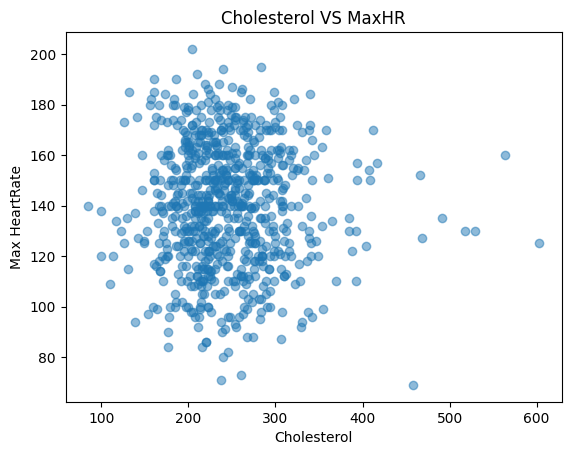

In [22]:
clean_df_plot = numeric[numeric['Cholesterol']>0]
plt.scatter(clean_df_plot['Cholesterol'],clean_df_plot['MaxHR'],alpha=0.5)
plt.xlabel("Cholesterol")
plt.ylabel("Max HeartRate")
plt.title('Cholesterol VS MaxHR')
plt.show()

#### Plot implies that there is no evident relationship between increase in Cholesterol nad Maximum Heart Rate in the patient data

<Axes: xlabel='FastingBS', ylabel='MaxHR'>

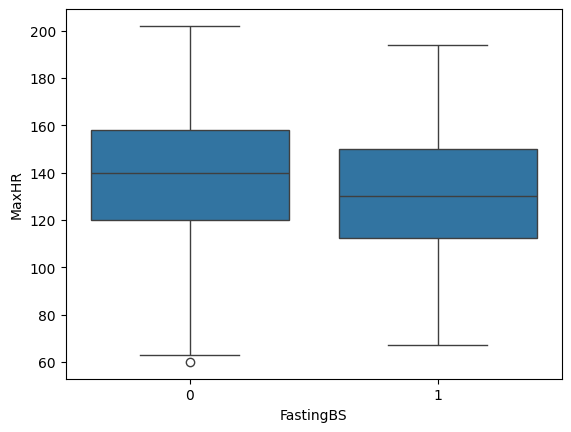

In [23]:
sns.boxplot(data=numeric,x='FastingBS',y='MaxHR')

### Helper function to visualize boxplot of Target/Feature and it's distribution and how it affecets the patient state:

In [24]:
# x axis will be HeartDisease -> target var
# y axis will be other features 
# boxplot 
selected_feature = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
def plot_boxplot(X,features):

    x1 = 'HeartDisease'
    n = len(features)
    print(features)
    fig,ax = plt.subplots(1,n,figsize=(10,6))

    for ax,feature in zip(ax.flatten(),features):
        sns.boxplot(data=X,x=x1,y=feature,ax=ax)
        plt.tight_layout()


['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


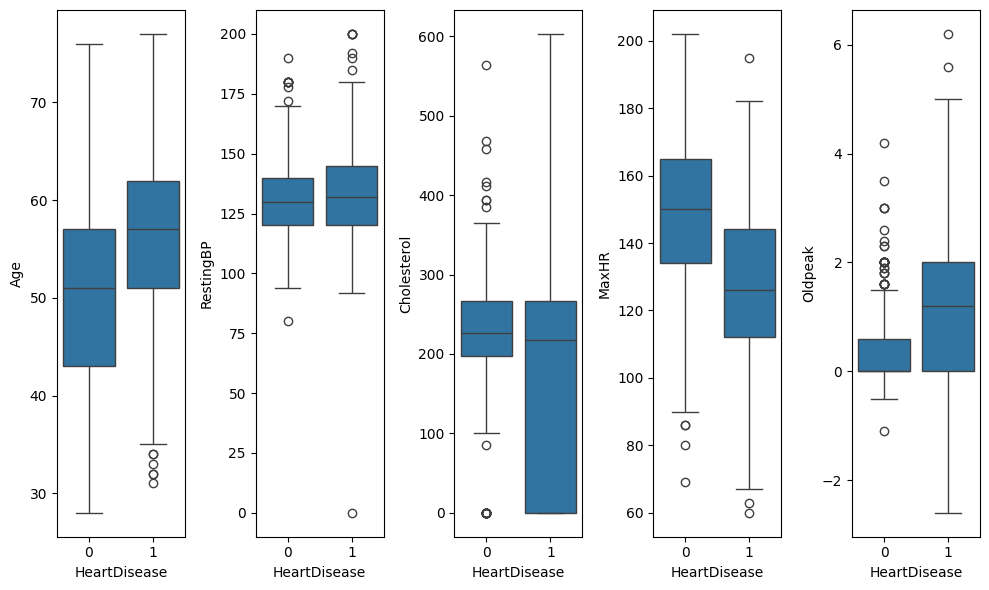

In [25]:
plot_boxplot(df,selected_feature)

### Summary of boxplot:

1) Age -> expected behaviour, showing that patients that are older have higher disease incidence, while having some outliers in the lower bound for positive class. From this data and dataset, we do not know anything about history of the patients, their lifestyle and maybe some co-morbidities present.

2) RestingBP -> Median for both classes is similar, while positive class has slighlty higher distribution spread, towrads the higher values of BP. We can not conclude that RestingBP affect the Heart Disease.

3) Cholesterol -> From the boxplot, we may conclude that Cholesterol is not such a good variable for discriminating between postiive and negative class. We need to take into consideration that Cholesterol variable has 170+ missing values, and like this, it's not informative.


4) Max Heart Rate -> We see that patients with no disease have higher maximum heart rate, which could be explained by the heart capacity to sustain exercise.  Lower max heart rate , and evidently lower mean value, indicate that this variable is informative in prediction task 

5) Oldpeak (Degree of ST segment depression measured on ECG during a **stress test** compared to a baseline at rest) 

- During an exercise, heart works harder to pump blood. If patient has some arterial plaque or calcification, they cannot supply enoguh bloodflow

- This shortage causes downward shift (depression) in the ECG ST segment

- downward shift >= 1.5-2 is implying significant indicator of coronar artery disease. 

<Axes: xlabel='RestingBP', ylabel='MaxHR'>

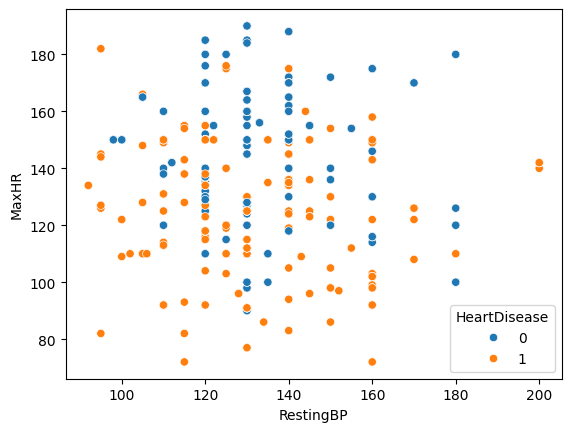

In [26]:
#resting bp , max hr and cholesterol
numeric_no_zero = numeric.loc[cholesterol_no_zeros,:]
numeric_no_zero['HeartDisease'] = df['HeartDisease']
sns.scatterplot(x=numeric_no_zero['RestingBP'],y=numeric_no_zero['MaxHR'],hue=numeric_no_zero['HeartDisease'])

### Cholesterol - has missing values. -> Candidate for imputation in the preprocessing 

- median imputation

In [27]:
# Cholesterol
# in the original dataset:

df['Cholesterol'] = df['Cholesterol'].replace(0,np.nan)
df['Cholesterol'].isna().sum() # 172 sum values


np.int64(172)

### **1.4 EDA visualisation of the data ( Categorical features )**

In [28]:
# categorical features from dataset

categorical = df.select_dtypes(exclude='number')
categorical

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [29]:
categorical.groupby("RestingECG")['Sex'].describe()

,count,unique,top,freq
RestingECG,,,,
LVH,188,2,M,141
Normal,552,2,M,434
ST,178,2,M,150


<Axes: xlabel='RestingECG', ylabel='count'>

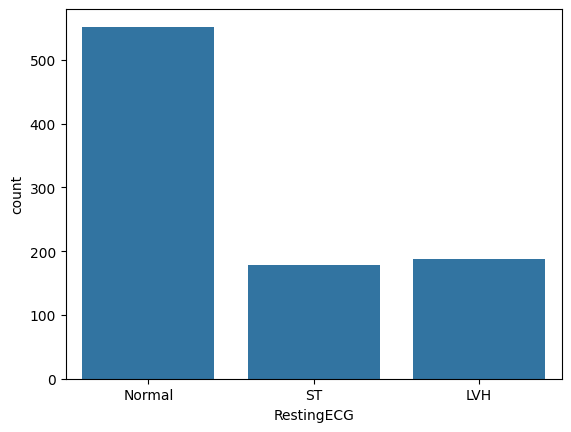

In [30]:
sns.countplot(data=categorical,x='RestingECG')

In [31]:
categorical.groupby('ExerciseAngina')['RestingECG'].describe()

,count,unique,top,freq
ExerciseAngina,,,,
N,547,3,Normal,345
Y,371,3,Normal,207


<Axes: xlabel='ExerciseAngina', ylabel='count'>

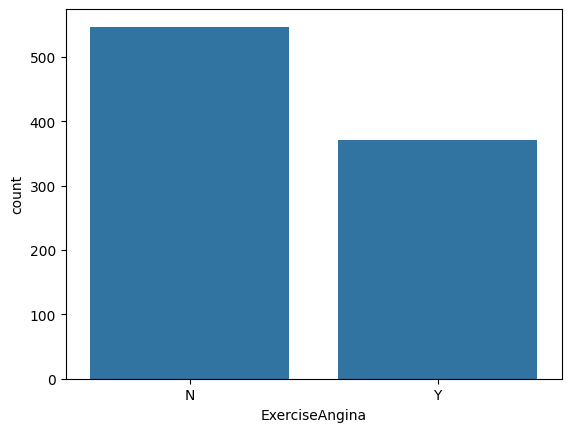

In [32]:
sns.countplot(data=categorical,x='ExerciseAngina')

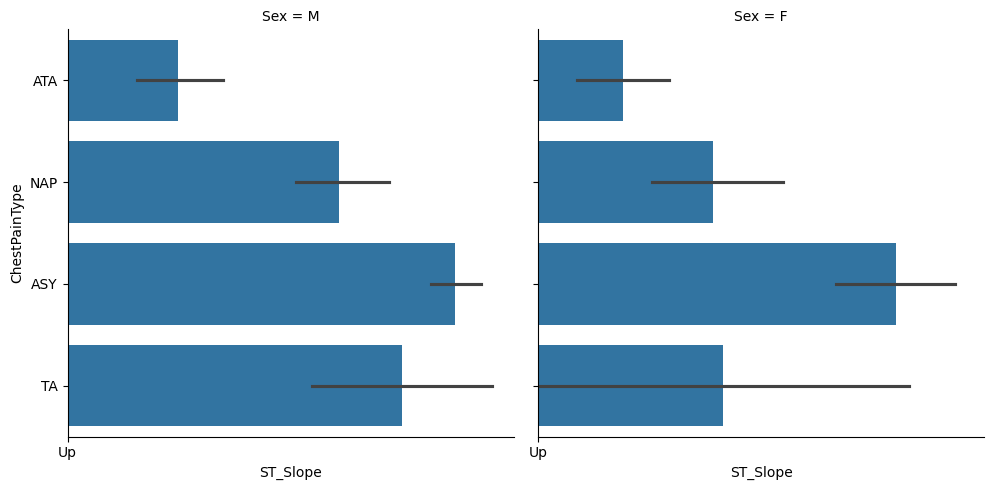

In [33]:
sns.catplot(categorical,kind='bar',
            x='ST_Slope',y='ChestPainType',col='Sex',orient='h')

### **Preprocessing**

- Train/Test split

- Column Transformer + Pipe

- Missing values imputation

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'X_Train :{X_train.shape}')
print(f"X_test:{X_test.shape}")


X_Train :(734, 11)
X_test:(184, 11)


In [35]:
chol = df['Cholesterol'].isna()==True
chol.sum()
z = chol.sum()/len(df)
z # 18% of feature has missing values

df['Cholesterol'].describe()
# mean imputation would be suitable

count    746.000000
mean     244.635389
std       59.153524
min       85.000000
25%      207.250000
50%      237.000000
75%      275.000000
max      603.000000
Name: Cholesterol, dtype: float64

In [36]:
df.isna().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           0
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [37]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

In [38]:
for col in categorical.columns:
    print(col,categorical[col].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


**ST_SLOPE** -> Ordinal categories, have rank from mild to worse condition up -> flat -> down

In [39]:
slope_size = categorical['ST_Slope'].unique()
slope_size

array(['Up', 'Flat', 'Down'], dtype=object)

In [40]:
preprocessing = ColumnTransformer(transformers=[
    ('imputer',SimpleImputer(strategy='mean'),['Cholesterol']),
    ('labelEncoder',OrdinalEncoder(),['Sex','ExerciseAngina']),
    ('OrdinalEncoder',OrdinalEncoder(categories=[slope_size]),['ST_Slope']),
    ('Ohe',OneHotEncoder(),['ChestPainType','RestingECG'])],
    remainder='passthrough')

## Preprocessing test on SingleTree

In [41]:
mini_pipe = make_pipeline(
    preprocessing,
    DecisionTreeClassifier()
)

mini_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer', ...), ('labelEncoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.

In [42]:
from sklearn.metrics import precision_score,recall_score,classification_report
y_pred = mini_pipe.predict(X_test)
report = classification_report(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
print(f"Baseline precision: {precision}")
print(f"Baseline recall: {recall}\n")
print(report)

Baseline precision: 0.8541666666666666
Baseline recall: 0.7663551401869159

              precision    recall  f1-score   support

           0       0.72      0.82      0.76        77
           1       0.85      0.77      0.81       107

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.80      0.79      0.79       184



## **Modeling** - Baseline with crossvalidation (k=5)

### Models: 

- Single Classification Tree (baseline)

- RandomForest

- XGCBoost

### Scores:

- f1

- precision

- accuracy

- roc_auc

- precision_recall

In [43]:
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import accuracy_score,precision_recall_curve,roc_auc_score,roc_curve,f1_score

In [44]:
models = {
    'Tree':DecisionTreeClassifier(random_state=42),
    'Forest':RandomForestClassifier(random_state=42),
    'Xboost':XGBClassifier(random_state=42)
}

In [45]:
# pipeline (preprocessing + model) 

complete_pipeline = {}

for name,model in models.items():
    make_pipe = make_pipeline(
        preprocessing,
        model
    )
    complete_pipeline[name] = make_pipe

In [46]:
score_list = ['f1','accuracy','precision','recall','roc_auc']

def get_scores(X,y,pipe,scores):
    score_storage = {}


    for name,estimator in pipe.items():
        score_storage[name] = {}

        for score in scores:
            result = cross_val_score(estimator,X,y,scoring=score,cv=5)
            score_storage[name][score] = result.mean().round(2)
    return score_storage


In [47]:
baseline_score = get_scores(X_train,y_train,complete_pipeline,score_list)

In [48]:
baseline_score_pd = pd.DataFrame(baseline_score)
baseline_score_pd.T.sort_values(by='f1',ascending=False)

,f1,accuracy,precision,recall,roc_auc
Forest,0.88,0.87,0.86,0.90,0.92
Xboost,0.87,0.86,0.86,0.89,0.92
Tree,0.78,0.76,0.79,0.77,0.76


In [49]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

y_preds = {}
y_probas = {}

for name,model in complete_pipeline.items():
    y_hat = cross_val_predict(model,X_train,y_train,cv=5,method='predict')
    y_preds[name]= y_hat
    probas = cross_val_predict(model,X_train,y_train,cv=5,method='predict_proba')[:,1]
    y_probas[name] = probas

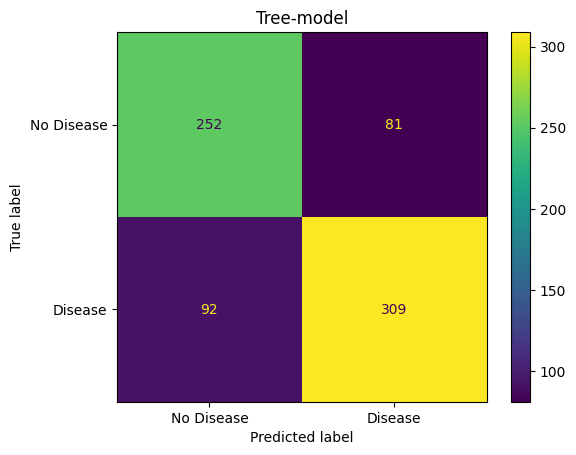

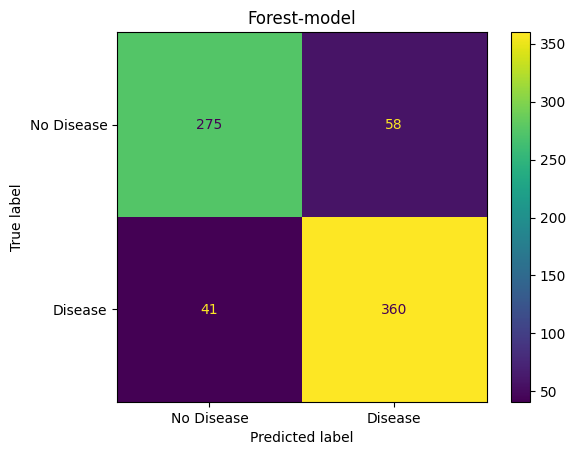

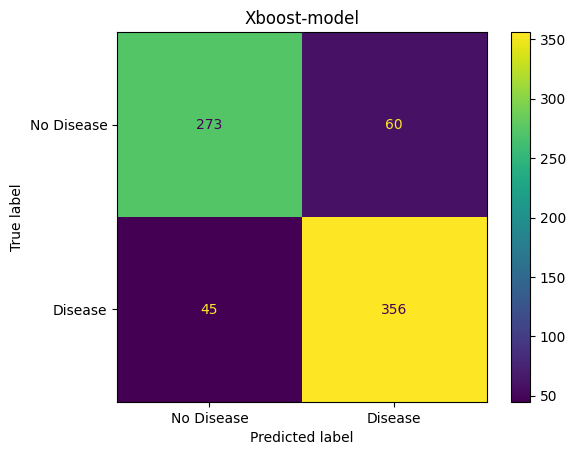

In [50]:
collect = {}
for name,preds in y_preds.items():
    cm = confusion_matrix(y_train,preds,labels=[0,1])
    tn,fp,fn,tp = cm.ravel()
    collect[name] = tn,fp,fn,tp
    z = ConfusionMatrixDisplay(cm,display_labels=['No Disease','Disease'])
    z.plot()
    z.ax_.set_title(f'{name}-model')

In [51]:
values_df = pd.DataFrame(collect)

In [52]:
values_df.rename(mapper={0:'tn',1:'fp',2:'fn',3:'tp'},inplace=True)

In [53]:
values_df.T.sort_values(by='tp',ascending=False)

,tn,fp,fn,tp
Forest,275,58,41,360
Xboost,273,60,45,356
Tree,252,81,92,309


### RandomForest baseline model shows highest number of **True Positives**/**False Negatives**

- In this data science problem, it is important to have less false negative and a lot of true positives 

- we want to capture all positive samples and eliminate most of false negatives. We dont want to say to a patient that he is not sick , and he is actually sick (Type 2 eror)

In [54]:
values_df

,Tree,Forest,Xboost
tn,252,275,273
fp,81,58,60
fn,92,41,45
tp,309,360,356


In [55]:

baseline_score_pd

,Tree,Forest,Xboost
f1,0.78,0.88,0.87
accuracy,0.76,0.87,0.86
precision,0.79,0.86,0.86
recall,0.77,0.90,0.89
roc_auc,0.76,0.92,0.92


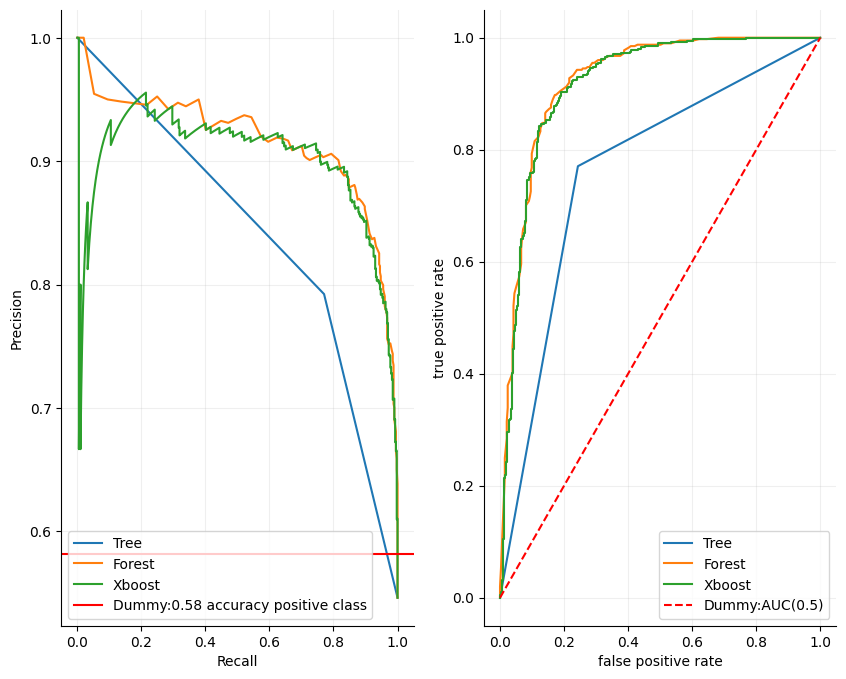

In [56]:
# ROC auc and PR curve
def plot_curves(complete_pipe,y,y_proba):

    storage = {}
    positive_class = sum(y_test==1)/len(y_test)

    fig,ax = plt.subplots(1,2,figsize=(10,8))
    for name,model in complete_pipe.items():
        storage[name] = {}
        precision,recall,threshold_pr = precision_recall_curve(y,y_proba[name])
        fpr,tpr,threshold_roc = roc_curve(y,y_proba[name])
        storage[name]['pr'] = precision
        storage[name]['rec'] = recall
        storage[name]['fpr'] = fpr
        storage[name]['tpr'] = tpr
    
    for i,(name,model) in enumerate(complete_pipe.items()):
        ax[0].plot(storage[name]['rec'],storage[name]['pr'],label=f"{name}")
        ax[1].plot(storage[name]['fpr'],storage[name]['tpr'],label=f"{name}")
    
    # Dummy classifier
    ax[0].axhline(positive_class,linestyle='-',color='red',label="Dummy:0.58 accuracy positive class")
    ax[1].plot([0,1],[0,1],color='red',linestyle='--',label='Dummy:AUC(0.5)')
    
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[1].set_xlabel("false positive rate")
    ax[1].set_ylabel("true positive rate")
    for i in range(len(ax)):
        ax[i].grid(alpha=0.2)
        ax[i].legend()
        ax[i].spines[['top','right']].set_visible(False)

z = plot_curves(complete_pipeline,y_train,y_probas)

### Precision Recall curve:

- Trade off between precision and recall. At highest values of precision, recall value is low. At low values of recal , precision suddenly drops and then stabilizes at high value. We aim to find a dot that points at highest value of recall with the possible highest value of precision. Since my goal is to detect most True Classes and less False negatives

### ROC curve:

It shows how well model can distinguish between positive and negative class. Red line represets the DummyClassifier which represents random class assign.


### We may see from the graph that RandomForest keeps highest precision for the highest values of recall

### Hyperparameters:

DT Hyperparameters are external configuration settings used to control the structure, growth, and complexity of a decision tree model. 

Because unconstrained decision trees naturally grow until they completely memorize the training data, tuning these settings is the primary defense 

against __overfitting__.



In [57]:
parameters = {
    'Tree':{'decisiontreeclassifier__max_depth':[1,2,3,4,6,8,16],'decisiontreeclassifier__min_samples_split':[2,4,8,16,32,64,128]},
    'Forest':{'randomforestclassifier__n_estimators':[10,50,100,500],'randomforestclassifier__min_samples_split':[2,4,8,16,32,64,128],'randomforestclassifier__max_depth':[2, 4, 8, 16]},
    'Xboost':{'xgbclassifier__n_estimators':[500],'xgbclassifier__learning_rate':[0.05,0.1,0.2,0.4],'xgbclassifier__verbosity':[1],'xgbclassifier__subsample':[0.8,1]}
            
}

#### All 3 models defined in the upper cell are tree based, thus they can use initial column_transformer ( same transformations are applied to same columns)

- preprocessing

In [58]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer', ...), ('labelEncoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

## GridSearchCV

- Class used for exhaustive search for parameters predefined 

- GridSearchCV try all possible combination of parameters:

example: 

max_depth: [2,4,7]
min_samples_leaf: [2,4,8]

**9 times the model is fit**

**While this can be computationally expensive, it's the best method to obtain best parameters in small-medium param. grid size.**

### Alternative: RandomizedSearchCV -> Picks random parameters to train the model **best used for small grids and fast execution**
---
**GridSearchCV**

- estimator

- param_grid: list or list of dicts with parameters 

- scoring

- n_jobs: -1 all cores utilization

- refit: **default: True** -> refits the estimator with best found parameters on the whole dataset

- cv: CV splitting strategy, specify k (number of folds used for test , k - 1 for training)

In [59]:
def grid_search(X,y,pipe,params,cv):

    grid_output = {}

    for name,model in pipe.items():
        grid_output[name] = {}
        estimator = model
        pars = params[name]
        g = GridSearchCV(estimator,pars,cv=cv,verbose=1,n_jobs=-1,scoring='f1',refit=True)
        g.fit(X,y)
        grid_output[name]['best_model'] = g.best_estimator_
        grid_output[name]['best_scores'] =g.best_score_
        grid_output[name]['cv_results'] = g.cv_results_
        grid_output[name]['best_params'] = g.best_params_
    return grid_output

tuning_output = grid_search(X_train,y_train,complete_pipeline,parameters,5)

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Fitting 5 folds for each of 112 candidates, totalling 560 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [60]:
best_models = {}
for name,values in tuning_output.items():
    print(values)
    best_models[name] = values['best_model']

{'best_model': Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer', SimpleImputer(),
                                                  ['Cholesterol']),
                                                 ('labelEncoder',
                                                  OrdinalEncoder(),
                                                  ['Sex', 'ExerciseAngina']),
                                                 ('OrdinalEncoder',
                                                  OrdinalEncoder(categories=[array(['Up', 'Flat', 'Down'], dtype=object)]),
                                                  ['ST_Slope']),
                                                 ('Ohe', OneHotEncoder(),
                                                  ['ChestPainType',
                                                   'RestingECG'])])),
                ('decisiontreeclassifier',
                 

In [61]:
collect_df_optimized = {}
probas_2 = {}
for name,model in best_models.items():
    collect_df_optimized[name] = {}
    probas_2[name] = {}
    y_preds = cross_val_predict(model,X_train,y_train,cv=5,method='predict')
    y_probas = cross_val_predict(model,X_train,y_train,cv=5,method='predict_proba')[:,1]
    probas_2[name] = y_probas
    for score in score_list:
        scores = cross_val_score(model,X_train,y_train,cv=5,scoring=score)
        collect_df_optimized[name][score] = scores.mean()

    

In [62]:
collect_df_optimized = pd.DataFrame(collect_df_optimized)

In [63]:
collect_df_optimized.sort_values(by='f1',ascending=False,axis=1)


,Forest,Xboost,Tree
f1,0.893527,0.861838,0.847931
accuracy,0.880095,0.847386,0.826950
precision,0.871471,0.857401,0.816935
recall,0.917778,0.867932,0.882809
roc_auc,0.924020,0.916101,0.863822


### PR and ROC curve with optimized hyperparameters:

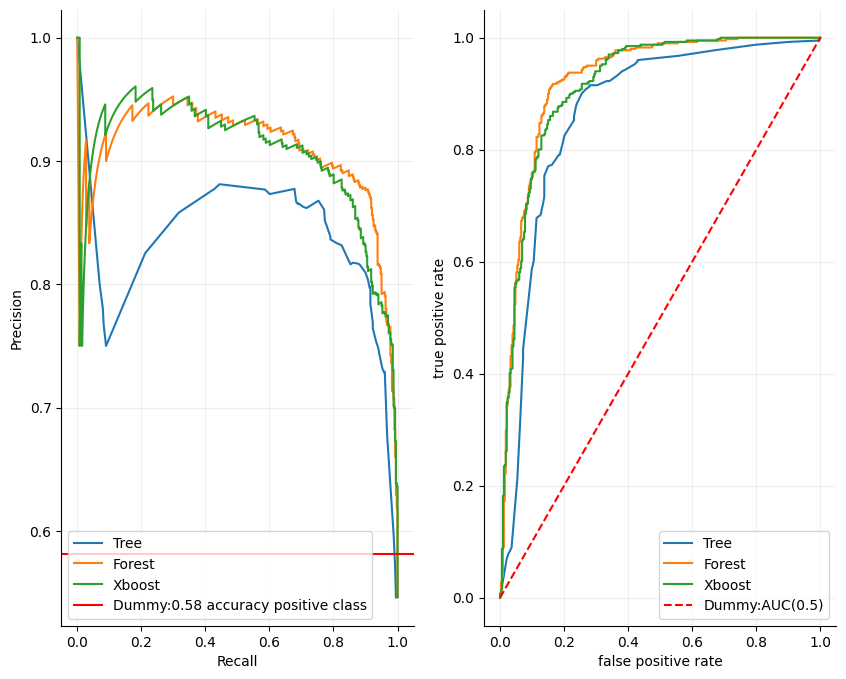

In [64]:
p = plot_curves(best_models,y_train,probas_2)

In [65]:
collect_df_optimized.sort_values(by='f1', ascending=False,axis=1).round(2)

,Forest,Xboost,Tree
f1,0.89,0.86,0.85
accuracy,0.88,0.85,0.83
precision,0.87,0.86,0.82
recall,0.92,0.87,0.88
roc_auc,0.92,0.92,0.86


In [66]:
baseline_score_pd.sort_values(by='f1',ascending=False,axis=1)

,Forest,Xboost,Tree
f1,0.88,0.87,0.78
accuracy,0.87,0.86,0.76
precision,0.86,0.86,0.79
recall,0.90,0.89,0.77
roc_auc,0.92,0.92,0.76


In [95]:
data_difference = baseline_score_pd.compare(collect_df_optimized)

In [96]:
data_difference.rename(mapper={'self':'baseline','other':'tuned_parameters'},axis=1,inplace=True)

In [97]:
data_difference

Tree                    Forest                    Xboost  \
          baseline tuned_parameters baseline tuned_parameters baseline   
f1            0.78         0.847931     0.88         0.893527     0.87   
accuracy      0.76         0.826950     0.87         0.880095     0.86   
precision     0.79         0.816935     0.86         0.871471     0.86   
recall        0.77         0.882809     0.90         0.917778     0.89   
roc_auc       0.76         0.863822     0.92         0.924020     0.92   

                            
          tuned_parameters  
f1                0.861838  
accuracy          0.847386  
precision         0.857401  
recall            0.867932  
roc_auc           0.916101

In [98]:
# Visualization of this multiindex col. dataframe
# 1) reset index
data_difference = data_difference.reset_index(col_level=1)

In [99]:
data_difference.rename(mapper={'index':'metrics'},axis=1,inplace=True)

In [101]:
data_difference.columns = data_difference.columns.map(mapper='_'.join)

In [105]:
data_difference = data_difference.round(2)
data_difference

,_metrics,Tree_baseline,Tree_tuned_parameters,Forest_baseline,Forest_tuned_parameters,Xboost_baseline,Xboost_tuned_parameters
0,f1,0.78,0.85,0.88,0.89,0.87,0.86
1,accuracy,0.76,0.83,0.87,0.88,0.86,0.85
2,precision,0.79,0.82,0.86,0.87,0.86,0.86
3,recall,0.77,0.88,0.90,0.92,0.89,0.87
4,roc_auc,0.76,0.86,0.92,0.92,0.92,0.92


In [112]:
var_cols = [c for c in data_difference.columns if c.endswith('_baseline') or c.endswith('_parameters')]
print(var_cols)
pd_melt = pd.melt(data_difference,id_vars=['_metrics'],value_vars=var_cols,var_name='model')

['Tree_baseline', 'Tree_tuned_parameters', 'Forest_baseline', 'Forest_tuned_parameters', 'Xboost_baseline', 'Xboost_tuned_parameters']


In [143]:
pd_melt.sort_values(by='value',ascending=False)

,_metrics,model,value
18,recall,Forest_tuned_parameters,0.92
29,roc_auc,Xboost_tuned_parameters,0.92
24,roc_auc,Xboost_baseline,0.92
19,roc_auc,Forest_tuned_parameters,0.92
14,roc_auc,Forest_baseline,0.92
13,recall,Forest_baseline,0.90
23,recall,Xboost_baseline,0.89
15,f1,Forest_tuned_parameters,0.89
16,accuracy,Forest_tuned_parameters,0.88
8,recall,Tree_tuned_parameters,0.88


In [150]:
recall_mask = pd_melt['_metrics'] == 'recall'
f1_mask = pd_melt['_metrics'] =='f1'
max_recall = pd_melt.loc[recall_mask,'value'].max()
max_f1= pd_melt.loc[f1_mask,'value'].max()
print(f"Max recall {max_recall}")
print(f"max f1: {max_f1}")

Max recall 0.92
max f1: 0.89


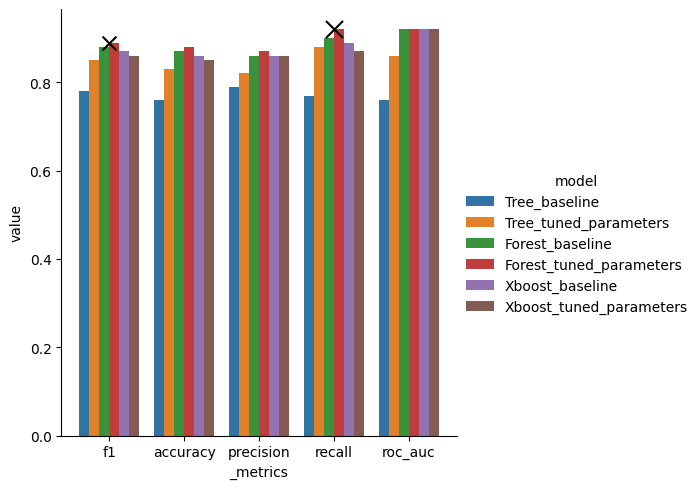

In [185]:
sns.catplot(data=pd_melt,x='_metrics',y='value',hue='model',kind='bar')
plt.scatter(x=3,y=max_recall,s=150,marker='x',color='black')
plt.scatter(x=0,y=max_f1,s=100,marker='x',color='black')

In [186]:
best_models.values()

dict_values([Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer', SimpleImputer(),
                                                  ['Cholesterol']),
                                                 ('labelEncoder',
                                                  OrdinalEncoder(),
                                                  ['Sex', 'ExerciseAngina']),
                                                 ('OrdinalEncoder',
                                                  OrdinalEncoder(categories=[array(['Up', 'Flat', 'Down'], dtype=object)]),
                                                  ['ST_Slope']),
                                                 ('Ohe', OneHotEncoder(),
                                                  ['ChestPainType',
                                                   'RestingECG'])])),
                ('decisiontreeclassifier',
                 De

In [187]:
tuning_output['Tree'].keys()

dict_keys(['best_model', 'best_scores', 'cv_results', 'best_params'])

### Score on validation fold on X_train set:

- scoring metric has been set to f1

- ['mean_test_score'] gives score on validation fold during CV.

In [188]:
tuning_output['Forest']['cv_results'].keys() # scoring parameter is set to 'f1' 
#tuning_output['Forest']['cv_results']['std_test_score'].mean()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_randomforestclassifier__max_depth', 'param_randomforestclassifier__min_samples_split', 'param_randomforestclassifier__n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

Dakle ono sto je bitno jeste da prikupim ceo output iz grid_output-a u recnik. 

Svaki model mora da ima best_estimator_, best_scores_, best_params_ i cv_results_

1) __best_estimator___ predstavlja model sa najboljom kombinacijom parametara -> daje najveci mean_test_score koji je odredjen metrikom u Gridu **scoring=f1**

2) __best_scores___ predstavlja najbolji mean cross-validovani skroz dobijen iz validation-folda tokom treniranja-> ovo je mean tih skorova iz svakog fold-a

3) __best_params___ predstavlja najbolje parametre koji imaju najveci mean test skor dobijen cross validacijom na validacionim foldovima

4) __cv_results___ dict sa svim metrikama

In [189]:
# Select FOREST

cv_df = pd.DataFrame(tuning_output['Forest']['cv_results'])
print(cv_df.columns)
cv_df[['mean_test_score','std_test_score','rank_test_score','params']].sort_values(by='mean_test_score',ascending=False)

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_randomforestclassifier__max_depth',
       'param_randomforestclassifier__min_samples_split',
       'param_randomforestclassifier__n_estimators', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')


,mean_test_score,std_test_score,rank_test_score,params
93,0.893527,0.019522,1,"{'randomforestclassifier__max_depth': 16, 'ran..."
94,0.892403,0.018361,2,"{'randomforestclassifier__max_depth': 16, 'ran..."
37,0.888678,0.017597,3,"{'randomforestclassifier__max_depth': 4, 'rand..."
97,0.888436,0.017208,4,"{'randomforestclassifier__max_depth': 16, 'ran..."
58,0.887802,0.014322,5,"{'randomforestclassifier__max_depth': 8, 'rand..."
...,...,...,...,...
17,0.865559,0.015345,103,"{'randomforestclassifier__max_depth': 2, 'rand..."
24,0.865316,0.007542,109,"{'randomforestclassifier__max_depth': 2, 'rand..."
25,0.863919,0.016626,110,"{'randomforestclassifier__max_depth': 2, 'rand..."
56,0.863071,0.009531,111,"{'randomforestclassifier__max_depth': 8, 'rand..."


In [190]:
cv_df.loc[cv_df['rank_test_score']==1,['mean_test_score','std_test_score','rank_test_score','params']]

,mean_test_score,std_test_score,rank_test_score,params
93,0.893527,0.019522,1,"{'randomforestclassifier__max_depth': 16, 'ran..."


In [78]:
# mean_test_score visok
# std nizak
# best 1% - highest mean test score

best_mean_score = cv_df['mean_test_score'].max()
best_mean_score
candidate = cv_df.loc[cv_df['mean_test_score']>=best_mean_score-0.01,['mean_test_score','std_test_score','rank_test_score','params']].sort_values(by='std_test_score',ascending=True)
candidate

,mean_test_score,std_test_score,rank_test_score,params
38,0.885981,0.014085,11,"{'randomforestclassifier__max_depth': 4, 'rand..."
34,0.884926,0.014224,17,"{'randomforestclassifier__max_depth': 4, 'rand..."
58,0.887802,0.014322,5,"{'randomforestclassifier__max_depth': 8, 'rand..."
33,0.886519,0.014339,9,"{'randomforestclassifier__max_depth': 4, 'rand..."
90,0.885078,0.015012,16,"{'randomforestclassifier__max_depth': 16, 'ran..."
30,0.883895,0.015016,21,"{'randomforestclassifier__max_depth': 4, 'rand..."
41,0.885714,0.016198,12,"{'randomforestclassifier__max_depth': 4, 'rand..."
97,0.888436,0.017208,4,"{'randomforestclassifier__max_depth': 16, 'ran..."
98,0.886883,0.017266,6,"{'randomforestclassifier__max_depth': 16, 'ran..."
96,0.885712,0.017367,13,"{'randomforestclassifier__max_depth': 16, 'ran..."


### mean_test_score -> sum of 'f1' score on validation fold in CrossValidation 

### std_test_score -> how each fold score vary. 

## **rank_test_score** -> most stable model **rank_test_score** = 1

Nakon Grid Search analize ne gledam samo najbolji mean_test_score koji predstavlja avg. f1 skora po validation foldovima CrossValidacije, vec gledam i varijaciju izmedju foldova. Manja varijacija izmedju test foldova predstavlja stabilniji model. U ovom slucaju, model sa kombinacijom parametara koja pripada rank_test_score = 1 predstavlja ujedno i najveci mean_test_score ali i najmanji std_test_score i biram ove parametre.

### Jednostavnom proverom parametara best_estimator_ iz Grid-a, vidimo da su hiperparametri bas ti koje smo i ovde izabrali rucno

In [79]:
best_models['Forest'].get_params

<bound method Pipeline.get_params of Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer', SimpleImputer(),
                                                  ['Cholesterol']),
                                                 ('labelEncoder',
                                                  OrdinalEncoder(),
                                                  ['Sex', 'ExerciseAngina']),
                                                 ('OrdinalEncoder',
                                                  OrdinalEncoder(categories=[array(['Up', 'Flat', 'Down'], dtype=object)]),
                                                  ['ST_Slope']),
                                                 ('Ohe', OneHotEncoder(),
                                                  ['ChestPainType',
                                                   'RestingECG'])])),
                ('randomforestclassifi

In [80]:
selected_params_final = candidate.loc[candidate['rank_test_score']==1,'params']

In [81]:
selected_param_final_list = selected_params_final.to_list()[0]
selected_param_final_list

{'randomforestclassifier__max_depth': 16,
 'randomforestclassifier__min_samples_split': 8,
 'randomforestclassifier__n_estimators': 50}

In [82]:
prefix = 'randomforestclassifier__'
new_clean = {}

for name,value in selected_param_final_list.items():
    if name.startswith(prefix):
        new_clean[name[len(prefix):]] = value



In [83]:
new_clean

{'max_depth': 16, 'min_samples_split': 8, 'n_estimators': 50}

In [84]:
RF_final = RandomForestClassifier(**new_clean,random_state=42)
RF_final

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

#### Test set evaluation


In [85]:
RF_final.fit(X_train,y_train)

ValueError: could not convert string to float: 'M'